Exercício 1

Letra a)

Média amostral: 1.5
Método dos momentos - theta = 0.417
Método da verossimilhança - theta = 0.501


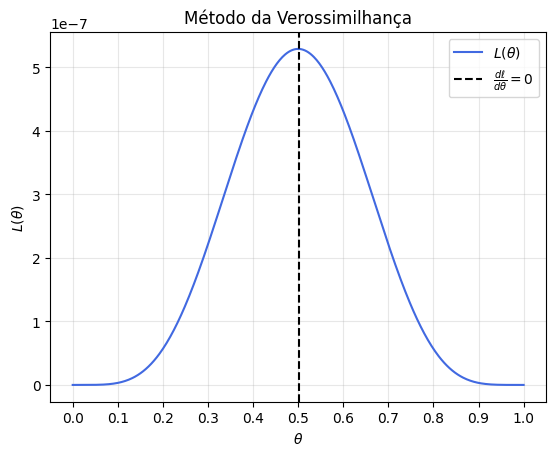

In [6]:
import numpy as np
import matplotlib.pyplot as plt

omega = [3,0,2,1,3,2,1,0,2,1]

media_amostral = np.mean(omega)
print('Média amostral:', media_amostral)
thetas = np.linspace(0,1,500)

#Método dos Momentos

momento1 = np.zeros(len(thetas))
erro = np.zeros(len(momento1))

for i in range(len(thetas)):
    momento1[i] = (1/3)*thetas[i] + (2/3)*(2*(1-thetas[i])) + (1-thetas[i])
    erro[i] = np.abs(momento1[i] - media_amostral)/media_amostral

thetaMM = thetas[np.argmin(erro)]
print(f'Método dos momentos - theta = {thetaMM:.3f}')

# Método da Verossimilhança

L = np.zeros(len(thetas))
n_termos = np.unique(omega)
freqs = np.zeros(len(n_termos))
for j in range(len(L)):
    for k in range(len(freqs)):
        freqs[k] = np.sum(omega == n_termos[k])
    L[j] = ((2/3)*thetas[j])**freqs[0] * (thetas[j]/3)**freqs[1] *  (
        (2*(1-thetas[j]))/3)**freqs[2] * ((1-thetas[j])/3)**freqs[3]

thetaVM = thetas[np.argmax(L)]
print(f'Método da verossimilhança - theta = {thetaVM:.3f}')

plt.figure()
plt.grid(alpha=0.3)
plt.plot(thetas,L,label=r'$L(\theta)$',color='royalblue')
plt.ylabel(r'$L(\theta)$')
plt.xlabel(r'$\theta$')
plt.axvline(x = thetas[np.argmax(L)],label=r'$\frac{d\ell}{d\theta}=0$',ls='--',color='black')
plt.legend()
plt.xticks(np.arange(np.min(thetas),np.max(thetas)+0.1,0.1))
plt.title('Método da Verossimilhança')
plt.show()

Letra b)

In [7]:
theta_real = 0.75
n_termos = np.array([0,1,2,3])
thetas = np.linspace(0.001,0.999,1000)
def obs(N):
    omega = []
    for i in range(N):
        X = np.random.choice([0,1,2,3],p=[(2*theta_real)/3,theta_real/3,(2*(1-theta_real))/3,(1-theta_real)/3])
        X = int(X)
        omega.append(X)
    return omega

N_sims = 1000
n_sims = np.arange(10,N_sims + 1)
theta_EMM = []
theta_EVM = []
for h in range(len(n_sims)):
    omega_sim = obs(n_sims[h])
    media_amostral = np.sum(omega_sim)/len(omega_sim)

    momento1 = np.zeros(len(thetas))
    erro = np.zeros(len(momento1))

    for i in range(len(thetas)):
        momento1[i] = (1/3)*thetas[i] + (2/3)*(2*(1-thetas[i])) + (1-thetas[i])
        erro[i] = np.abs(momento1[i] - media_amostral)/media_amostral

    thetaMM = thetas[np.argmin(erro)]

    L = np.zeros(len(thetas))
    freqs = np.zeros(len(n_termos))
    for j in range(len(L)):
        for k in range(len(freqs)):
            freqs[k] = np.sum(omega_sim == n_termos[k])
        L[j] = (freqs[0]*np.log((2/3)*thetas[j]) + freqs[1]*np.log(thetas[j]/3) + freqs[2]*np.log((2*(1-thetas[j]))/3) + freqs[3]*np.log((1-thetas[j])/3))
    thetaVM = thetas[np.argmax(L)]

    theta_EMM.append(thetaMM)
    theta_EVM.append(thetaVM)

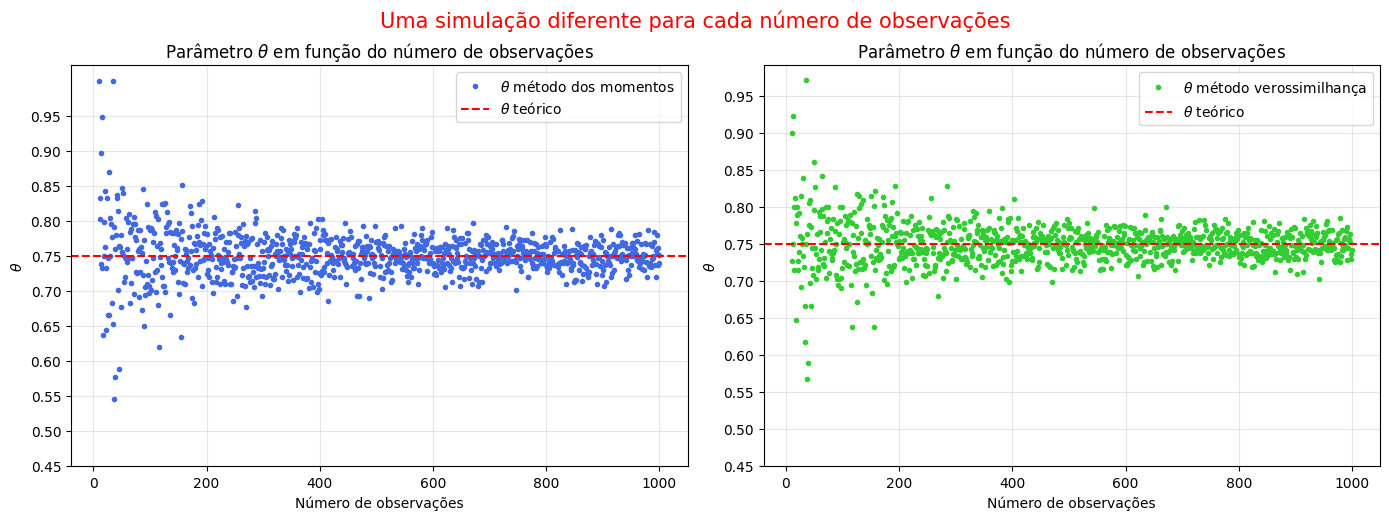

In [29]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].grid(alpha=0.3)
ax[0].set_title(r'Parâmetro $\theta$ em função do número de observações')
ax[0].plot(n_sims,theta_EMM,'o',color='royalblue',label=r'$\theta$ método dos momentos',ms=3)
ax[0].axhline(y=0.75,ls='--',color='red',label=r'$\theta$ teórico')
ax[0].set_xlabel('Número de observações')
ax[0].legend()
ax[0].set_ylabel(r'$\theta$')
ax[0].set_yticks(np.arange(0.45,1,0.05))
fig.text(0.5, 0.95, 'Uma simulação diferente para cada número de observações\n', ha='center',color='red',fontsize=15)

ax[1].grid(alpha=0.3)
ax[1].set_title(r'Parâmetro $\theta$ em função do número de observações')
ax[1].plot(n_sims,theta_EVM,'o',color='limegreen',label=r'$\theta$ método verossimilhança',ms=3)
ax[1].axhline(y=0.75,ls='--',color='red',label=r'$\theta$ teórico')
ax[1].set_xlabel('Número de observações')
ax[1].set_ylabel(r'$\theta$')
ax[1].legend()
ax[1].set_yticks(np.arange(0.45,1,0.05))

plt.tight_layout()
plt.show()